# Enrollment Analysis

## Purpose
This notebook explores student population size across four universities and examines how enrollment varies by institution type and location.

## Research Question
How does student population size differ across universities, and how might this influence local economic activity?

In [6]:
import pandas as pd

df = pd.read_csv("student_population.csv")
df.head()

,school,city,state,year,total_enrollment,undergrad_enrollment,graduate_enrollment,school_type,setting,source
0,University of California-Berkeley,Berkeley,CA,2020,43000,31000,12000,Public,Urban,IPEDS
1,University of California-Berkeley,Berkeley,CA,2021,44000,32000,12000,Public,Urban,IPEDS
2,University of California-Berkeley,Berkeley,CA,2022,45000,32500,12500,Public,Urban,IPEDS
3,University of California-Berkeley,Berkeley,CA,2023,45500,33000,12500,Public,Urban,IPEDS
4,University of California-Berkeley,Berkeley,CA,2024,45700,33000,12700,Public,Urban,IPEDS


## Observation Units

Each row represents a school-year observation.

Key variables:
- school
- year
- total_enrollment
- undergrad_enrollment
- graduate_enrollment

In [8]:
df.isnull().sum()

school                  0
city                    0
state                   0
year                    0
total_enrollment        0
undergrad_enrollment    0
graduate_enrollment     0
school_type             0
setting                 0
source                  0
dtype: int64

There are minimal missing values in the dataset. Any missing enrollment values will be excluded from analysis.

In [10]:
# percent undergrad
df["undergrad_share"] = df["undergrad_enrollment"] / df["total_enrollment"]

# growth over time
df["growth_rate"] = df.groupby("school")["total_enrollment"].pct_change()

## Key Dimensions

- Temporal: 2020–2024
- Spatial: Berkeley, Philadelphia, Ann Arbor, Middletown
- Institutional: Public vs Private

In [11]:
df.groupby("school")["total_enrollment"].mean().sort_values()

school
Wesleyan University                   3564.0
University of Pennsylvania           27260.0
University of California-Berkeley    44640.0
University of Michigan-Ann Arbor     49700.0
Name: total_enrollment, dtype: float64

Wesleyan has the smallest enrollment, while Michigan has the largest. This suggests large variation in potential local impact.

<Axes: xlabel='year'>

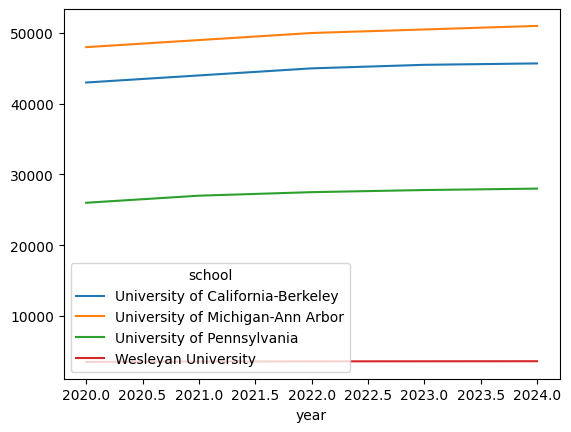

In [12]:
df.pivot(index="year", columns="school", values="total_enrollment").plot()

Enrollment has steadily increased across most universities, particularly at large public institutions.

In [13]:
df.groupby("school_type")["total_enrollment"].mean()

school_type
Private    15412.0
Public     47170.0
Name: total_enrollment, dtype: float64

Public universities tend to have significantly larger student populations than private institutions.

## Key Insights

- Large public universities (Michigan, Berkeley) have substantially higher enrollment.
- Smaller private institutions (Wesleyan) have a more limited population footprint.
- Enrollment growth is relatively stable across years.
- These differences likely influence local housing demand and business activity.